In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import signal
import copy
import pyfonts
import pywt

In [24]:
#Set global plotting parameters
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['figure.dpi'] = 600

font = pyfonts.load_google_font("Average Sans")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ['Arial']#, "DejaVu Sans", "Liberation Sans", "Verdana", "Arial", "Helvetica", "sans-serif"]
SIZE_DEFAULT = 10
plt.rcParams["font.size"] = SIZE_DEFAULT
plt.rcParams["axes.titlesize"] = SIZE_DEFAULT + 10
plt.rcParams["axes.labelsize"] = SIZE_DEFAULT + 8
plt.rcParams["xtick.labelsize"] = SIZE_DEFAULT
plt.rcParams["ytick.labelsize"] = SIZE_DEFAULT

fig_width = 6  # inches
fig_height = 4  # inches
plt.rcParams["figure.figsize"] = (fig_width, fig_height)


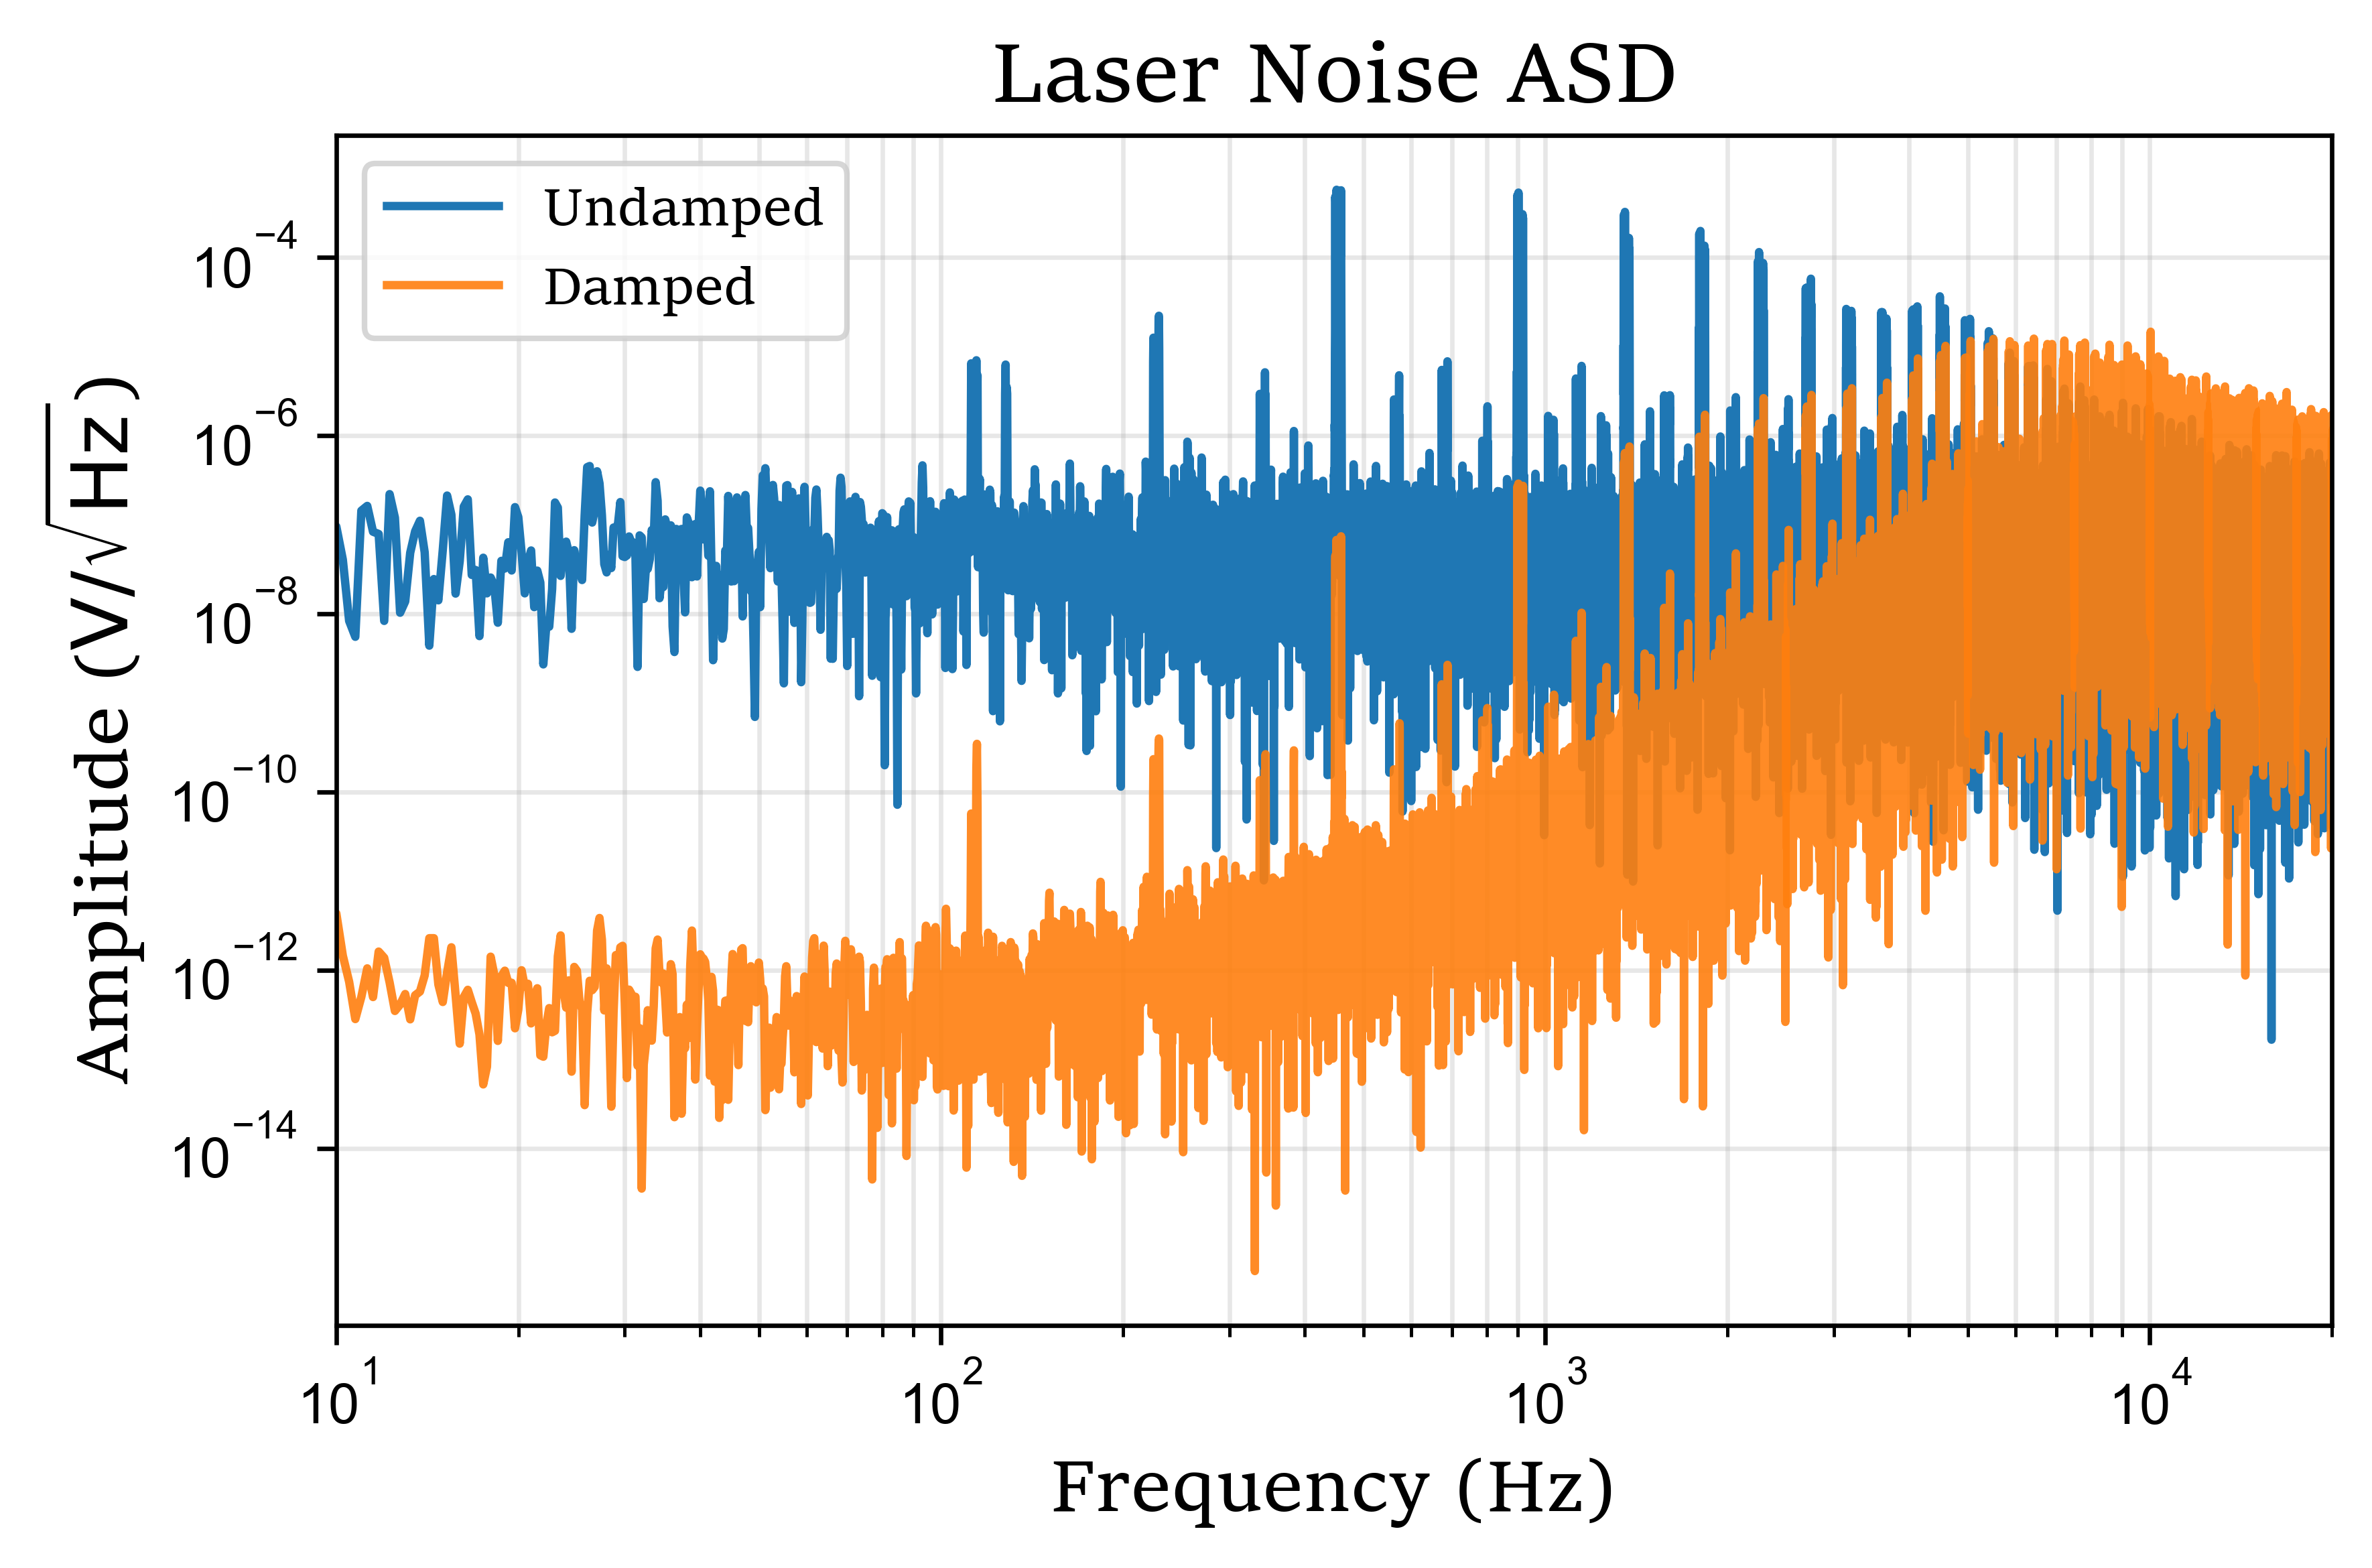

In [25]:
# Import two CSV files with Frequency and Amplitude columns
csv_path_1 = r"F:\laser noise data\20251014\laser_noise_psd_from_labview.csv"  # Update path as needed
csv_path_2 = r"F:\laser noise data\20251014\damped_psd_from_labview.csv"  # Update path as needed

# Read the CSV files
df_freq_1 = pd.read_csv(csv_path_1, usecols=[0, 1], names=["Frequency", "Amplitude"], skiprows=1)
df_freq_2 = pd.read_csv(csv_path_2, usecols=[0, 1], names=["Frequency", "Amplitude"], skiprows=1)

# Plot the two frequency response curves in separate figures
fig1, ax1 = plt.subplots()
#df_freq_1["Frequency"] = pd.to_numeric(df_freq_1["Frequency"], errors='coerce')
#df_freq_1["Amplitude"] = pd.to_numeric(df_freq_1["Amplitude"], errors='coerce')

ax1.loglog(df_freq_1["Frequency"], df_freq_1["Amplitude"],label="Undamped")
ax1.loglog(df_freq_2["Frequency"], df_freq_2["Amplitude"],label="Damped",alpha=0.9)
ax1.set_xlabel("Frequency (Hz)",font="Sitka",fontsize=SIZE_DEFAULT + 4)
ax1.set_ylabel(r"Amplitude ($\text{V}/\sqrt{\text{Hz}}$)",font="Sitka",fontsize=SIZE_DEFAULT + 4)
ax1.set_title("Laser Noise ASD",font="Sitka",fontsize=SIZE_DEFAULT + 6)
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc="upper left", prop={"family": "Sitka"})
ax1.set_xlim(10, 20000)  # Set x-axis limits to focus on the relevant frequency range
plt.tight_layout()
plt.show()



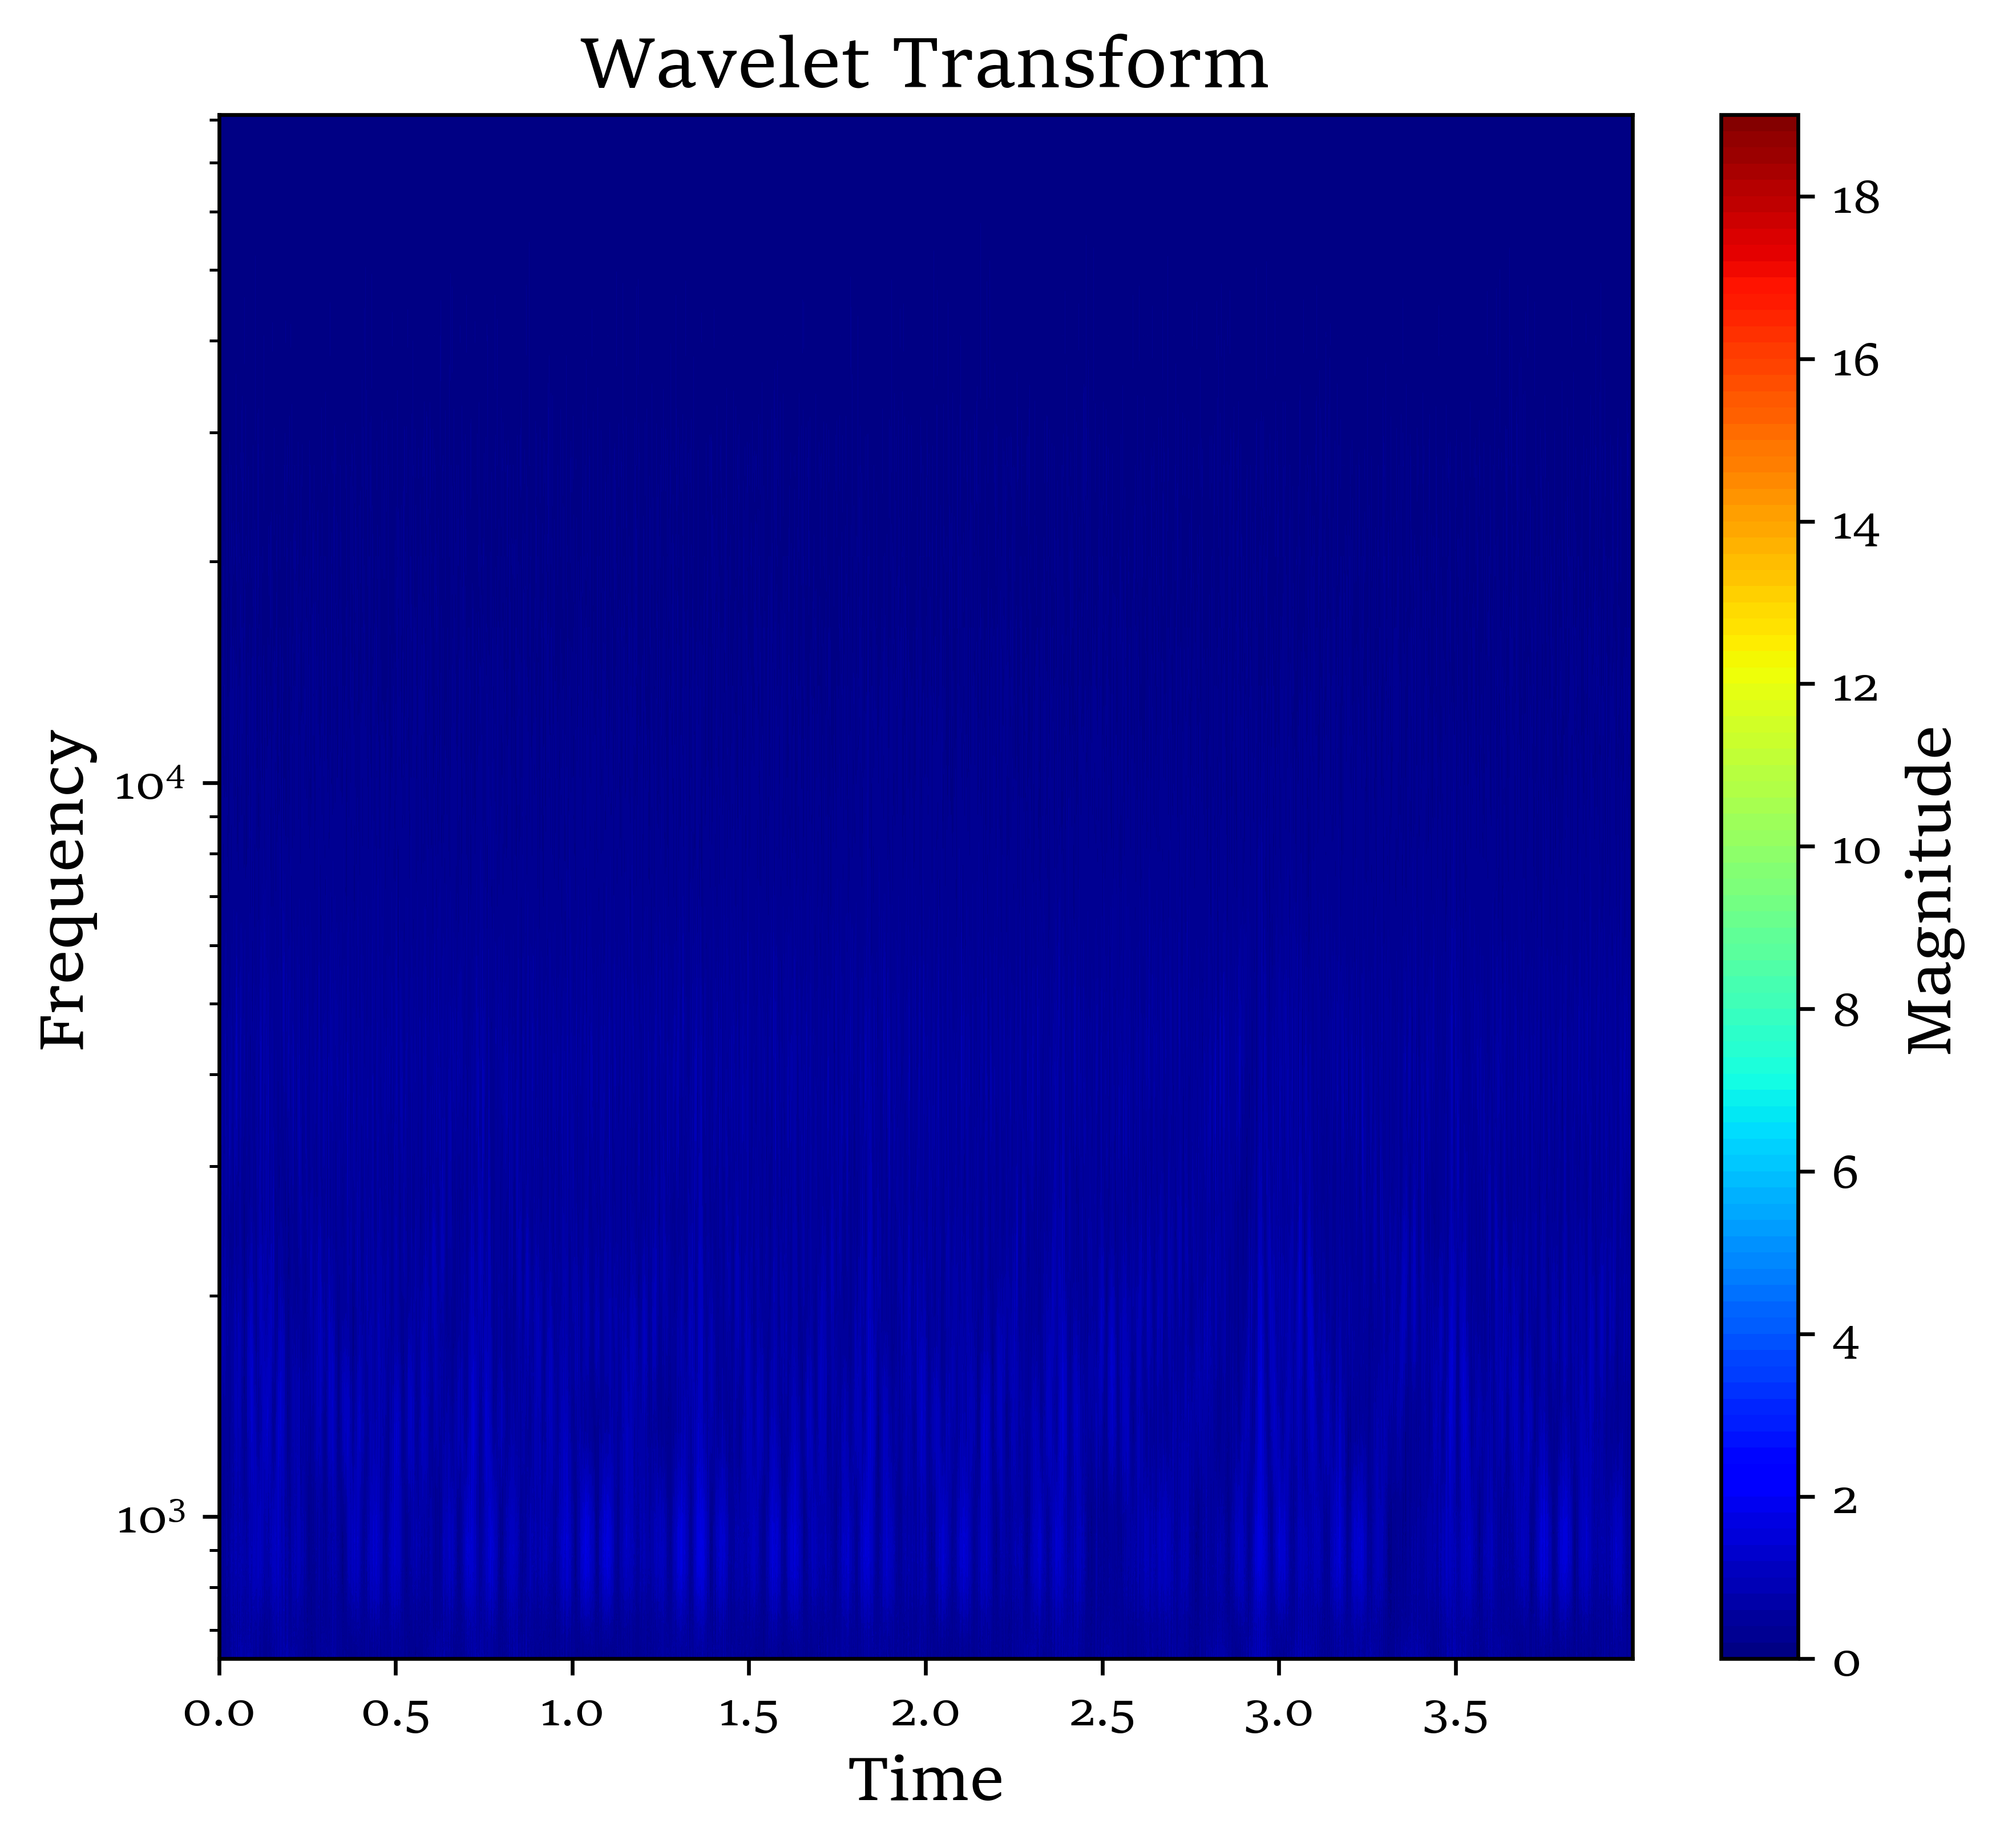

In [17]:
#sampling rate
fs = 100000 
# update this path to your CSV file
csv_path = r"F:\laser noise data\20251014\laser_noise_1.csv"

# read CSV (works whether or not the file has headers)
df_csv = pd.read_csv(csv_path)

# ensure there are at least two columns
if df_csv.shape[1] < 2:
    raise ValueError("CSV must contain at least two columns")

# store first column as 'time' and second as 'amplitude'
time = df_csv.iloc[:, 0].copy()
amplitude = df_csv.iloc[:, 1].copy()
time.name = "time"
amplitude.name = "amplitude"

# optional: combined dataframe with consistent names
df = pd.DataFrame({"time": time, "amplitude": amplitude})

sampling_period = 1/fs
widths = np.arange(1, 128)
# Perform continuous wavelet transform using PyWavelets
coefficients, frequencies = pywt.cwt(amplitude, widths, 'morl',sampling_period=sampling_period)

# Create wavelet plot
fig, ax = plt.subplots()
im = ax.contourf(time, frequencies, np.abs(coefficients), levels=100, cmap='jet')
ax.set_ylabel('Frequency')
ax.set_xlabel('Time')
ax.set_title('Wavelet Transform')
ax.set_yscale('log')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Magnitude')
plt.tight_layout()
plt.show()